<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/Daily_Water_Intake_%26_Hydration_Patterns_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Daily Water Intake & Hydration Patterns Dataset `[ ML Model Accuracy: 0.9857]`

# About the dataset and Insights

Dataset, focusing on 'Daily Water Intake and Hydration Patterns', offers a fascinating glimpse into factors influencing human hydration. It comprises diverse attributes like Age, Gender, Weight, actual Daily Water Intake (in liters), Physical Activity Level, Weather conditions, and the resulting Hydration Level (Good or Poor).

Our initial exploration confirmed the dataset's structure and data types. A crucial step was identifying and removing 338 duplicate entries, ensuring our subsequent analysis was based on unique and reliable observations.

Univariate analysis showed the general distribution of these factors – for instance, the age and weight ranges of participants, and the common occurrences of different physical activity levels and weather conditions.

Moving to bivariate analysis, we discovered compelling relationships. For example, individuals across all physical activity levels tended to maintain 'Good' hydration, but those with higher activity levels showed a stronger prevalence of good hydration. Similarly, 'Good' hydration was more common across all weather conditions, with a noticeable increase in water intake during 'Hot' weather. This suggests people naturally adjust their intake based on environmental cues.

Finally, our multivariate analysis painted a more detailed picture of how 'Daily Water Intake' is collectively shaped by multiple factors. We observed that daily water intake generally increases with physical activity. Males, on average, tended to consume more water than females. The most significant insight was the combined effect of weather. In 'Hot' conditions, water intake peaked, especially for highly active individuals. Conversely, intake was lowest in 'Cold' weather. This multi-faceted view helps us understand the complex interplay of demographics, lifestyle, and environment on hydration behavior.

These insights are invaluable for public health campaigns, personal hydration recommendations, or even product development in the health and wellness sector.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d sonalshinde123/daily-water-intake-and-hydration-patterns-dataset

# Unziping the downloaded file
!unzip daily-water-intake-and-hydration-patterns-dataset.zip

Saving kaggle.json to kaggle (1).json
Dataset URL: https://www.kaggle.com/datasets/sonalshinde123/daily-water-intake-and-hydration-patterns-dataset
License(s): CC0-1.0
  0% 0.00/192k [00:00<?, ?B/s]
100% 192k/192k [00:00<00:00, 524MB/s]
Archive:  daily-water-intake-and-hydration-patterns-dataset.zip
  inflating: Daily_Water_Intake.csv  


In [5]:
df = pd.read_csv('Daily_Water_Intake.csv')
df.head(11)

,Age,Gender,Weight (kg),Daily Water Intake (liters),Physical Activity Level,Weather,Hydration Level
0,56,Male,96,4.23,Moderate,Hot,Good
1,60,Male,105,3.95,High,Normal,Good
2,36,Male,68,2.39,Moderate,Cold,Good
3,19,Female,74,3.13,Moderate,Hot,Good
4,38,Male,77,2.11,Low,Normal,Poor
5,39,Female,93,2.81,Low,Normal,Good
6,59,Male,104,3.89,Moderate,Hot,Good
7,64,Female,106,3.78,Moderate,Hot,Good
8,69,Female,108,2.91,Low,Normal,Poor
9,54,Female,95,2.93,Moderate,Cold,Good


In [6]:
df.tail(11)

,Age,Gender,Weight (kg),Daily Water Intake (liters),Physical Activity Level,Weather,Hydration Level
29989,45,Male,81,2.94,Low,Hot,Good
29990,40,Male,59,2.46,Moderate,Normal,Good
29991,39,Male,53,1.50,Moderate,Cold,Poor
29992,24,Female,67,3.50,High,Hot,Good
29993,42,Male,76,2.75,Moderate,Normal,Good
29994,44,Male,108,3.40,Low,Cold,Good
29995,47,Male,97,3.45,Moderate,Cold,Good
29996,49,Female,109,5.32,High,Hot,Good
29997,56,Female,54,1.50,Moderate,Cold,Poor
29998,36,Male,106,4.00,Low,Hot,Good


In [7]:
df.shape

(30000, 7)

In [8]:
df.columns

Index(['Age', 'Gender', 'Weight (kg)', 'Daily Water Intake (liters)',
       'Physical Activity Level', 'Weather', 'Hydration Level'],
      dtype='object')

In [9]:
df.dtypes

,0
Age,int64
Gender,object
Weight (kg),int64
Daily Water Intake (liters),float64
Physical Activity Level,object
Weather,object
Hydration Level,object


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          30000 non-null  int64  
 1   Gender                       30000 non-null  object 
 2   Weight (kg)                  30000 non-null  int64  
 3   Daily Water Intake (liters)  30000 non-null  float64
 4   Physical Activity Level      30000 non-null  object 
 5   Weather                      30000 non-null  object 
 6   Hydration Level              30000 non-null  object 
dtypes: float64(1), int64(2), object(4)
memory usage: 1.6+ MB


In [11]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,30000.0,NaN,NaN,NaN,43.467667,14.99894,18.0,30.0,43.0,56.0,69.0
Gender,30000,2,Male,15032,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Weight (kg),30000.0,NaN,NaN,NaN,76.8486,18.74494,45.0,61.0,77.0,93.0,109.0
Daily Water Intake (liters),30000.0,NaN,NaN,NaN,2.852444,0.835537,1.5,2.22,2.83,3.44,5.43
Physical Activity Level,30000,3,High,10069,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Weather,30000,3,Hot,10081,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Hydration Level,30000,2,Good,23915,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
df.isnull().sum()

,0
Age,0
Gender,0
Weight (kg),0
Daily Water Intake (liters),0
Physical Activity Level,0
Weather,0
Hydration Level,0


In [13]:
df.duplicated().sum()

np.int64(338)

# Dropping Duplicate Values

In [14]:
print(f"Shape of DataFrame before dropping duplicates: {df.shape}")
df.drop_duplicates(inplace=True)
print(f"Shape of DataFrame after dropping duplicates: {df.shape}")

Shape of DataFrame before dropping duplicates: (30000, 7)
Shape of DataFrame after dropping duplicates: (29662, 7)


# Visualization

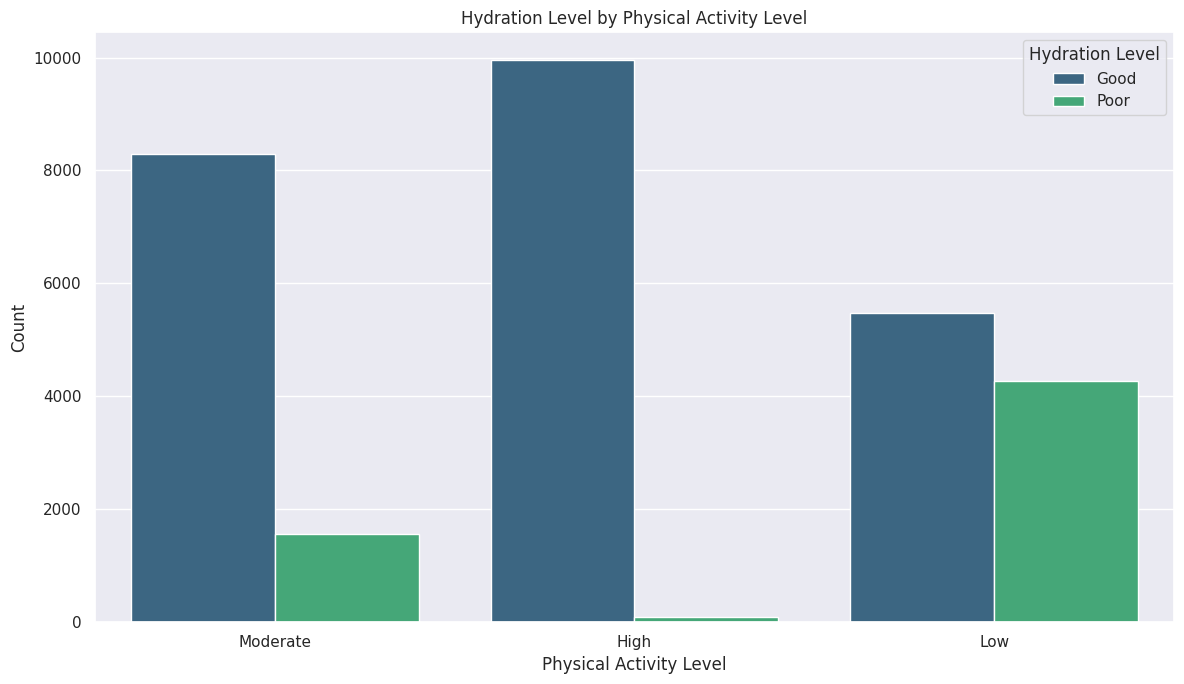

In [20]:
plt.figure(figsize=(12, 7))
sns.countplot(data=df, x='Physical Activity Level', hue='Hydration Level', palette='viridis')
plt.title('Hydration Level by Physical Activity Level')
plt.xlabel('Physical Activity Level')
plt.ylabel('Count')
plt.legend(title='Hydration Level')
plt.tight_layout()
plt.show()

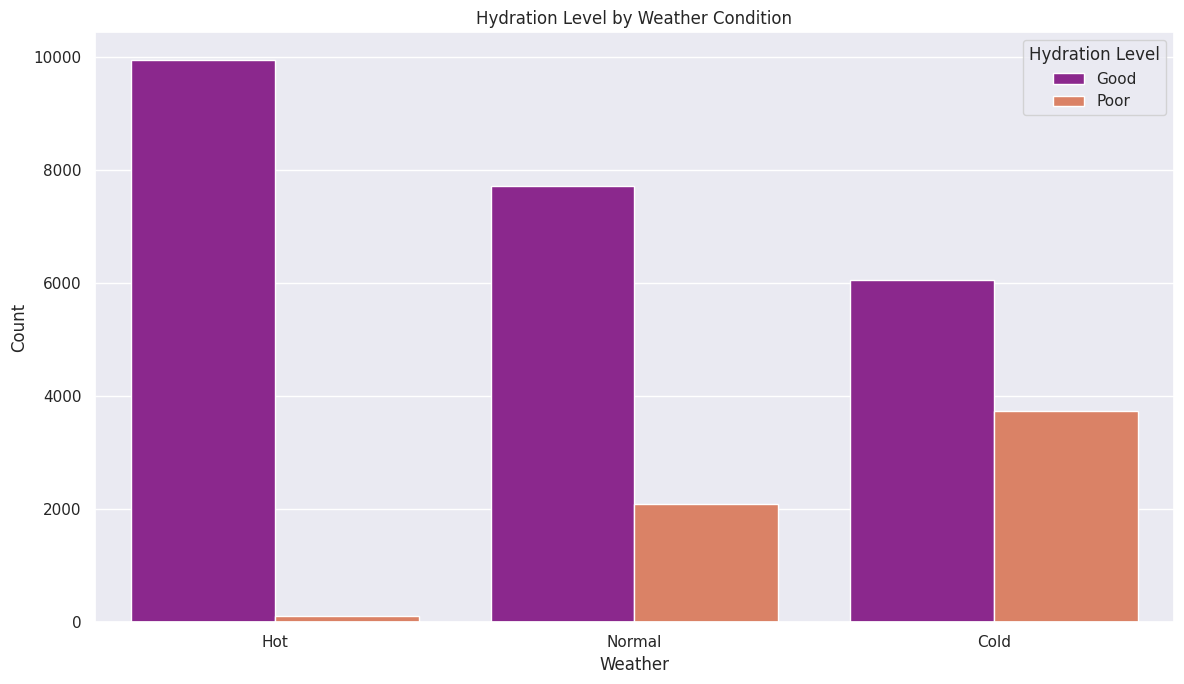

In [21]:
plt.figure(figsize=(12, 7))
sns.countplot(data=df, x='Weather', hue='Hydration Level', palette='plasma')
plt.title('Hydration Level by Weather Condition')
plt.xlabel('Weather')
plt.ylabel('Count')
plt.legend(title='Hydration Level')
plt.tight_layout()
plt.show()

To visualize the multivariate relationship between 'Daily Water Intake (liters)' and the categorical variables 'Gender', 'Physical Activity Level', and 'Weather', we can use a `catplot`. This plot type allows us to compare the distribution of the numerical variable across different categories and subcategories.

<Figure size 1400x800 with 0 Axes>

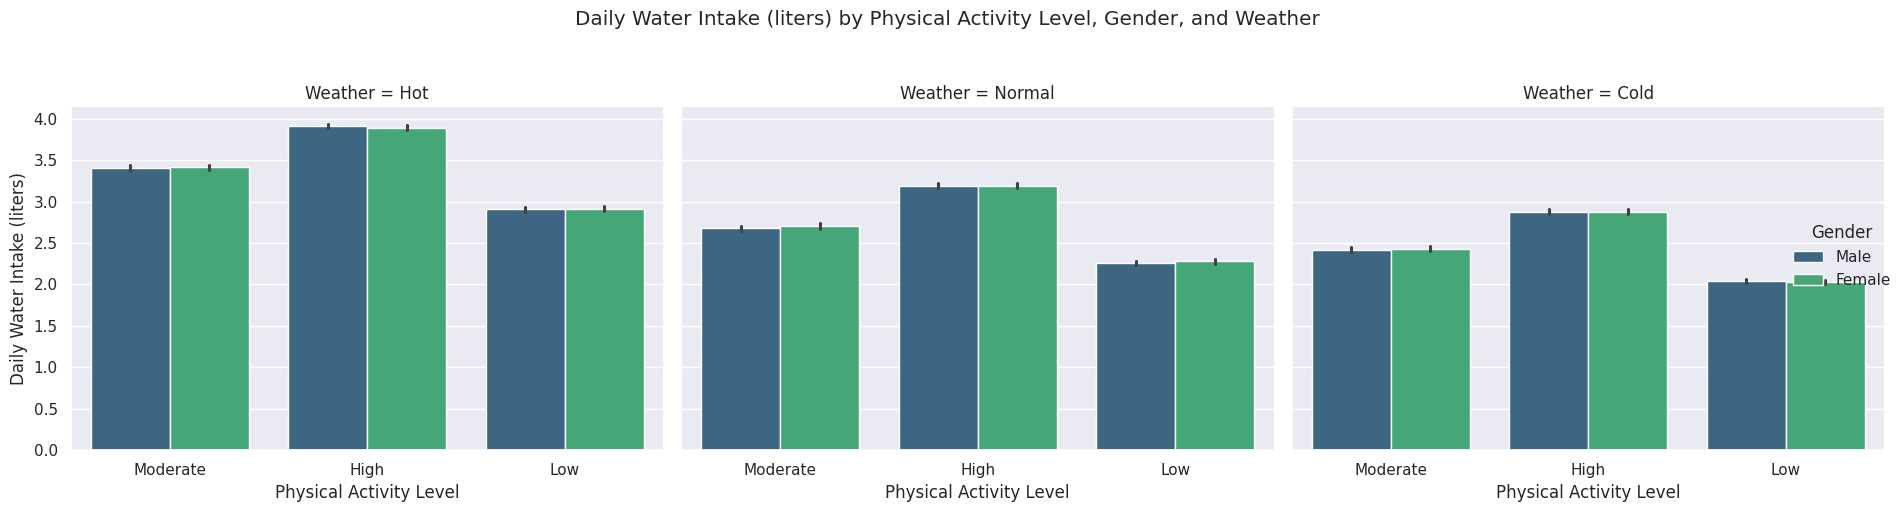

In [22]:
plt.figure(figsize=(14, 8))
sns.catplot(
    data=df,
    x='Physical Activity Level',
    y='Daily Water Intake (liters)',
    hue='Gender', # Group by Gender
    col='Weather', # Create separate plots for each Weather condition
    kind='bar', # Use bar plot to show mean and confidence interval
    palette='viridis',
    height=5,
    aspect=1.2
)

plt.suptitle('Daily Water Intake (liters) by Physical Activity Level, Gender, and Weather', y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.show()

# Univariate Analysis

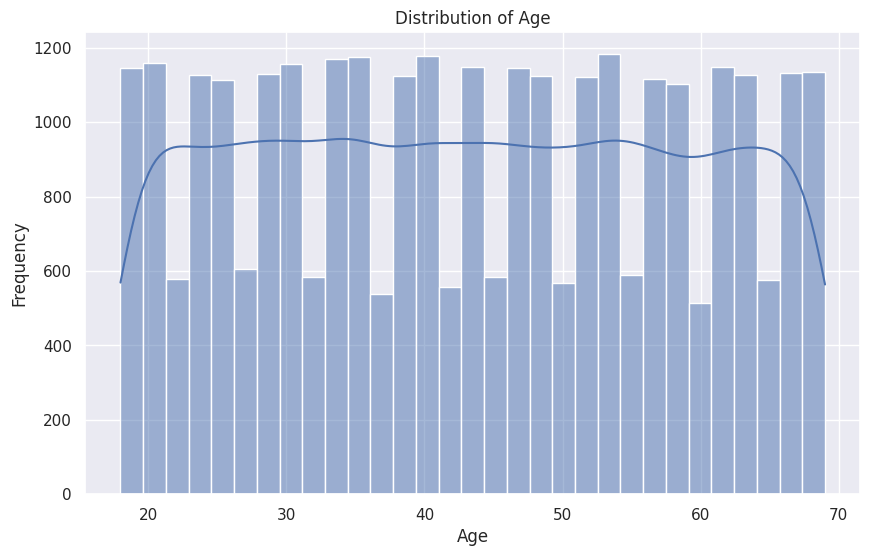

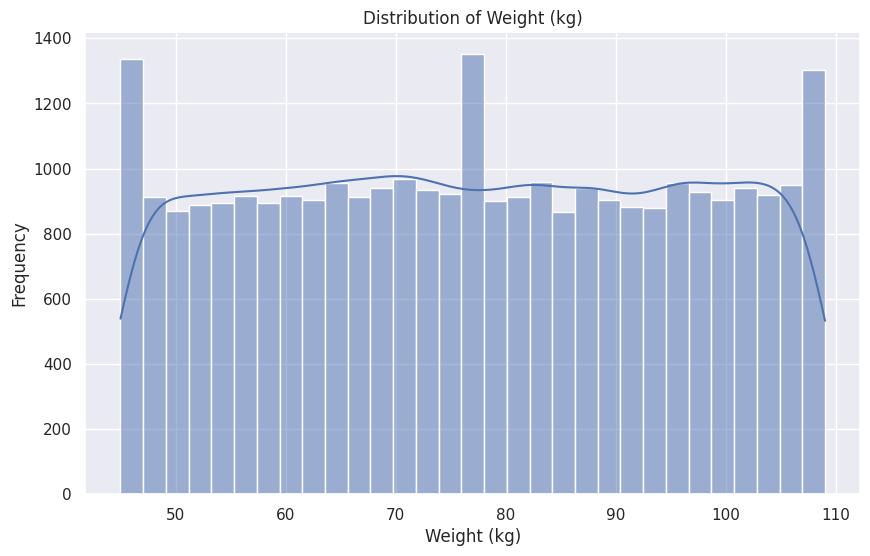

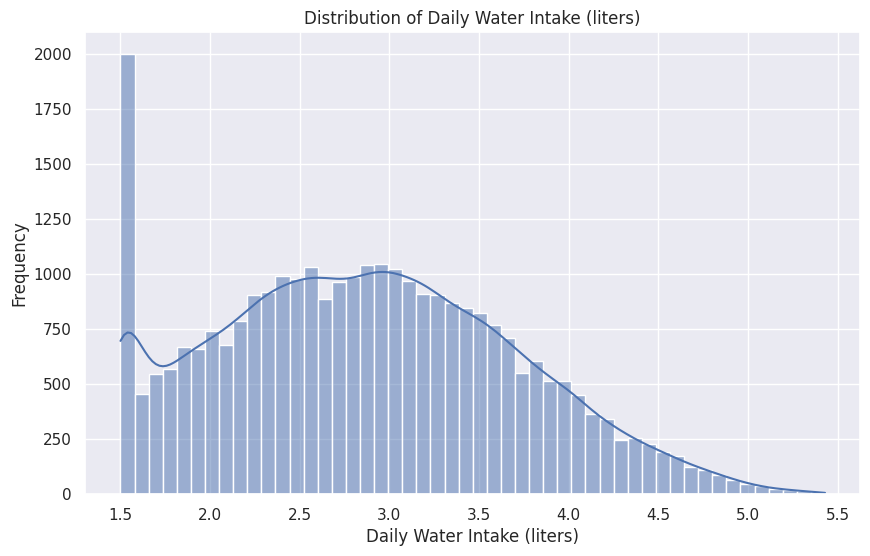

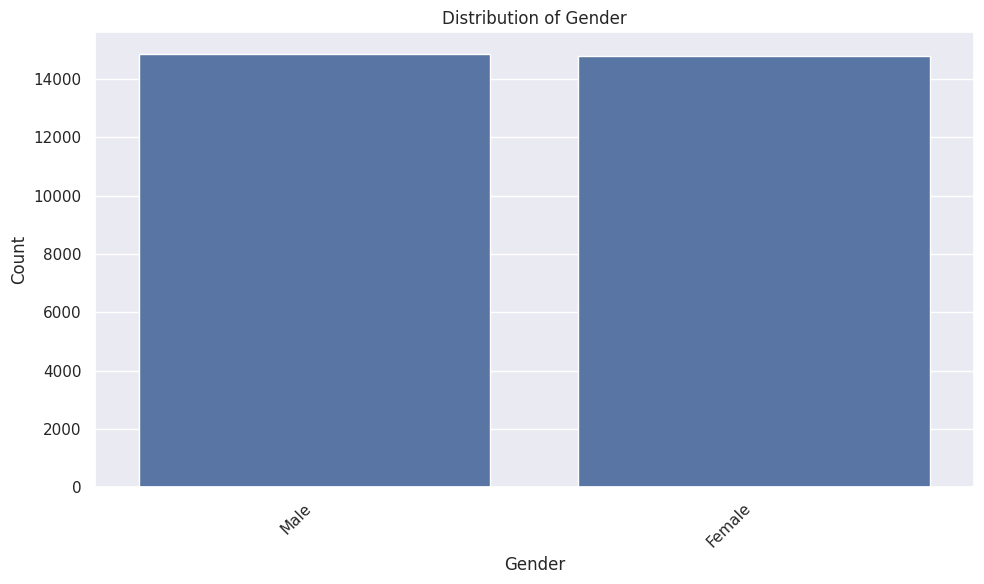

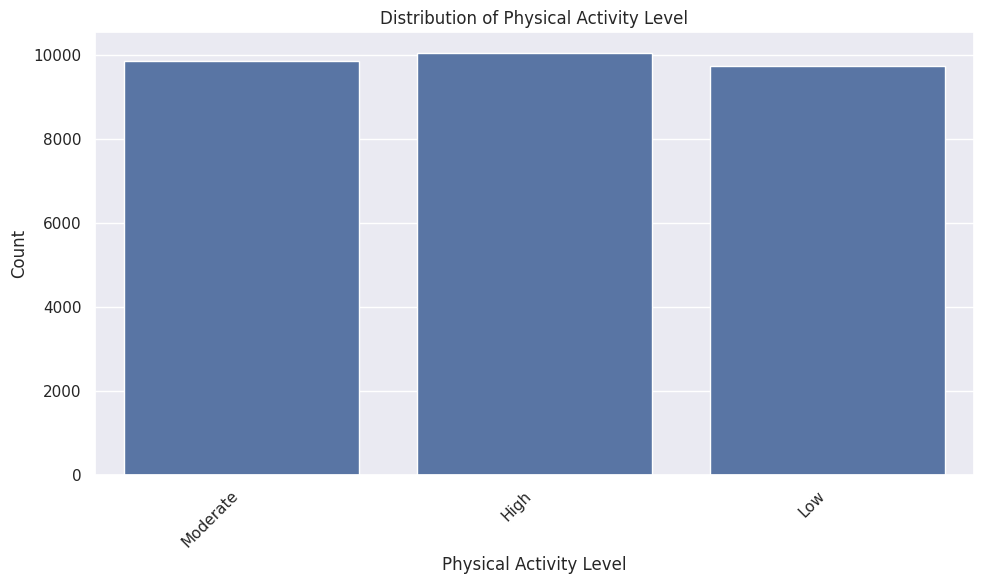

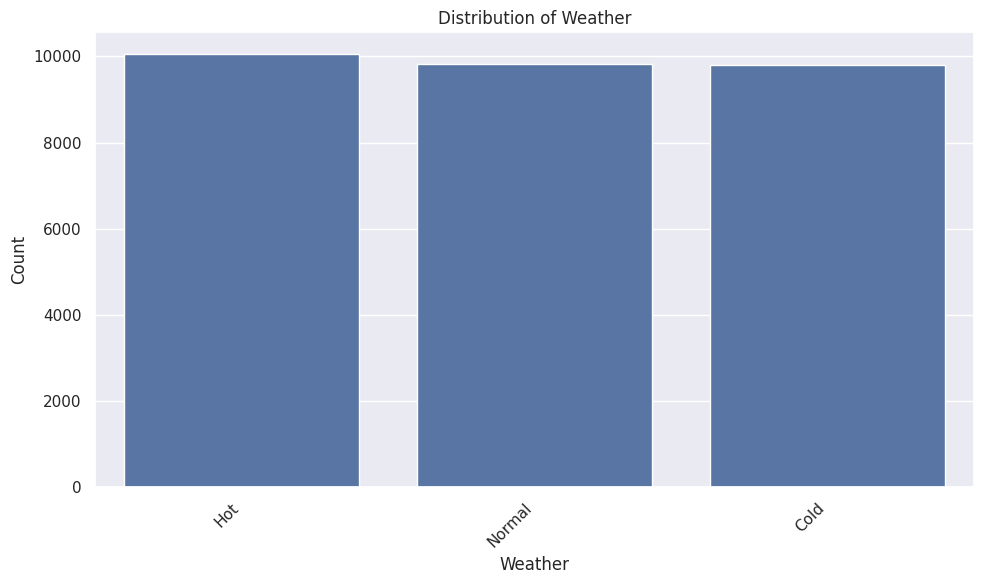

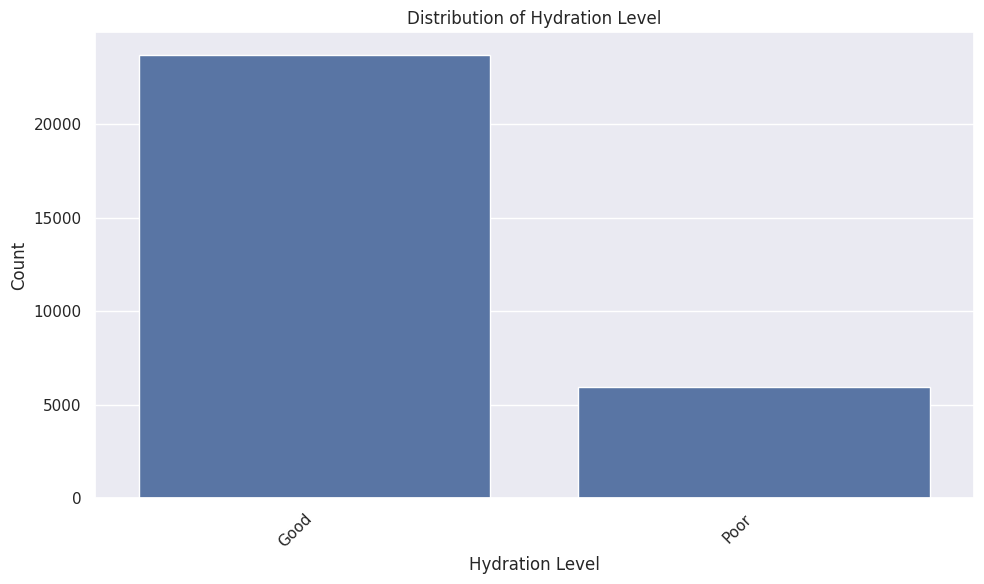

Value counts for Gender:
Gender
Male      14857
Female    14805
Name: count, dtype: int64

Value counts for Physical Activity Level:
Physical Activity Level
High        10046
Moderate     9860
Low          9756
Name: count, dtype: int64

Value counts for Weather:
Weather
Hot       10053
Normal     9811
Cold       9798
Name: count, dtype: int64

Value counts for Hydration Level:
Hydration Level
Good    23730
Poor     5932
Name: count, dtype: int64



In [15]:
# Getting a list of numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterating through numerical columns and create histograms
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Getting a list of categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Iterate through categorical columns and create countplots
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# We can also use value_counts for a quick look at categorical data distribution
for col in categorical_cols:
    print(f"Value counts for {col}:\n{df[col].value_counts()}\n")

# Bivariate Analysis

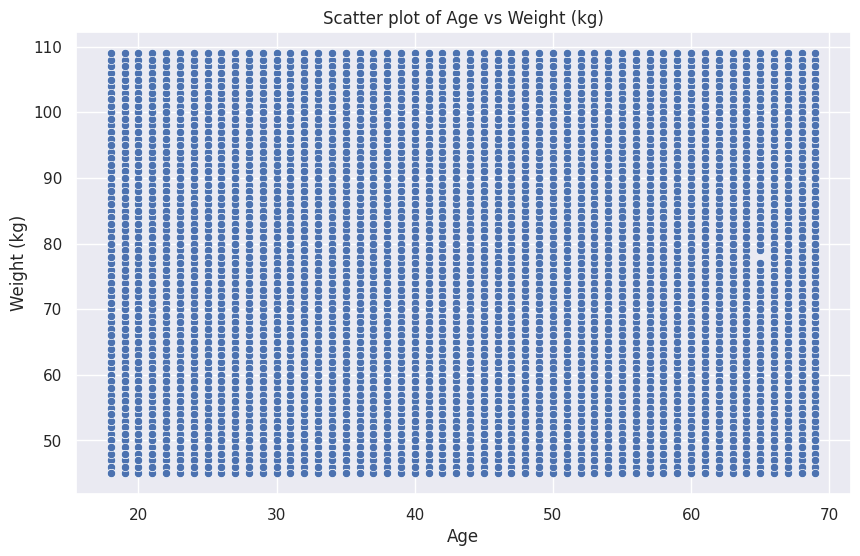

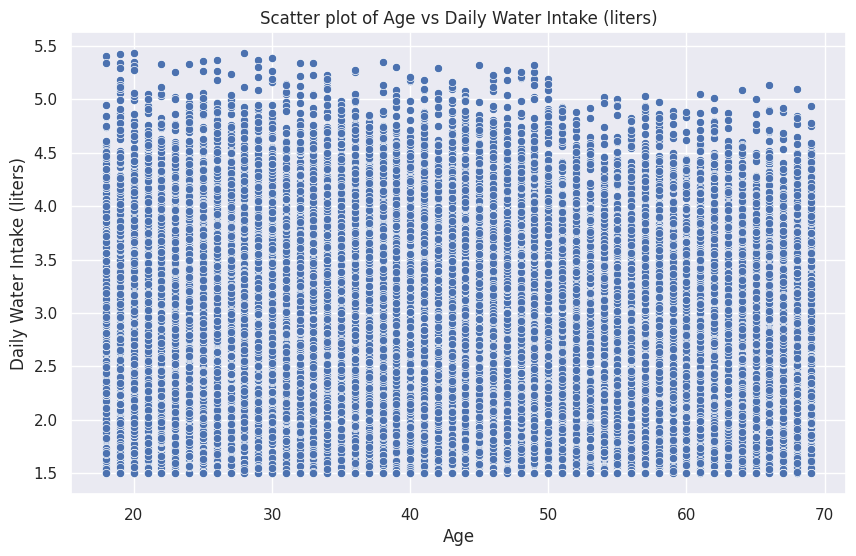

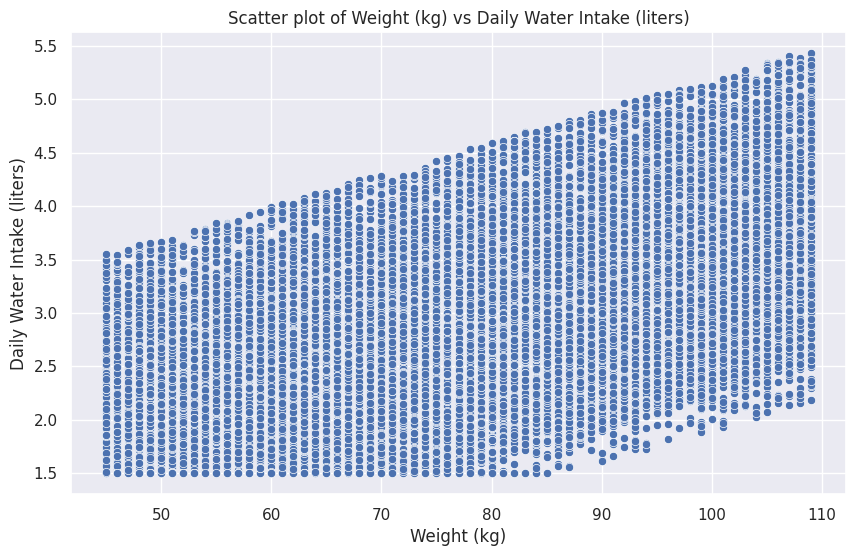

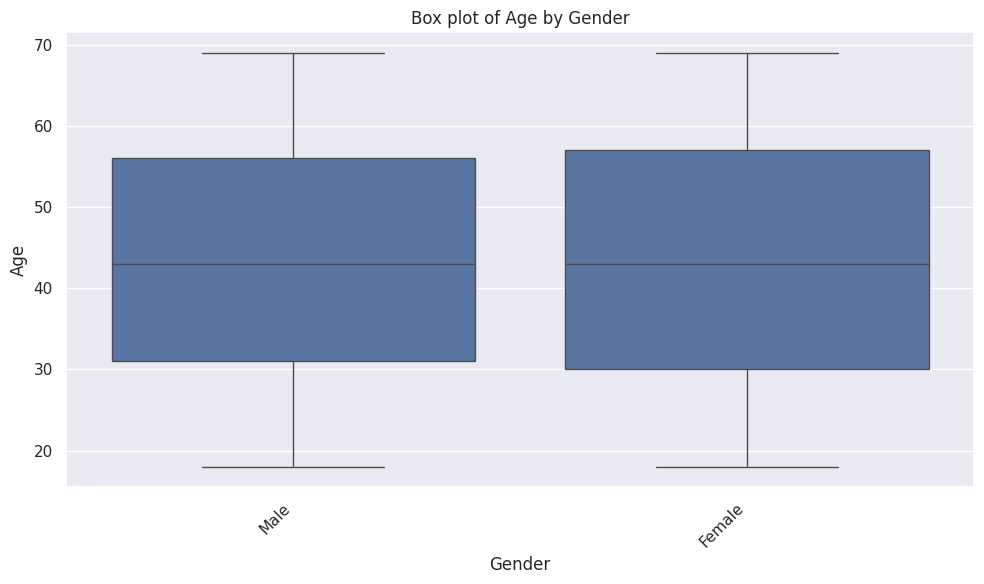

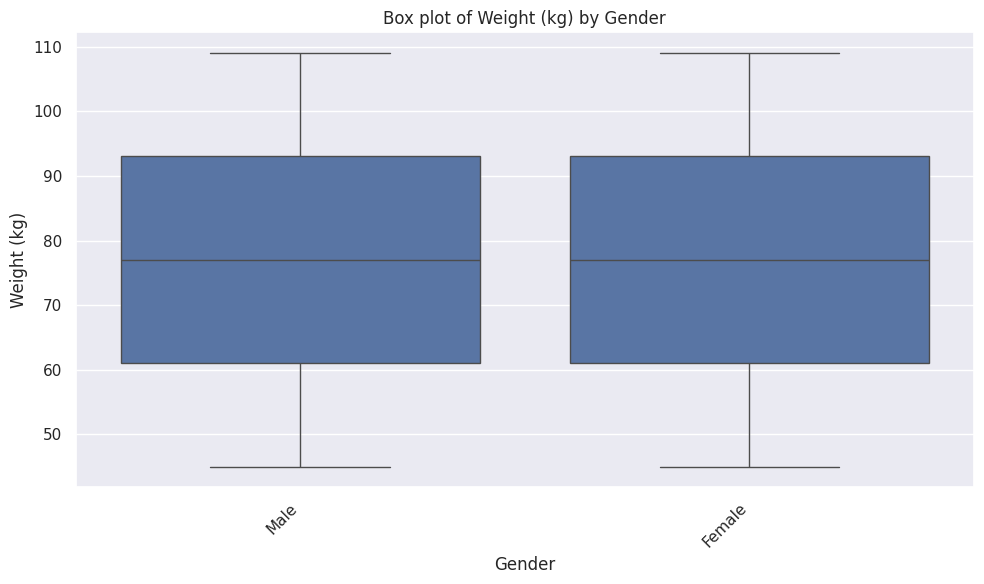

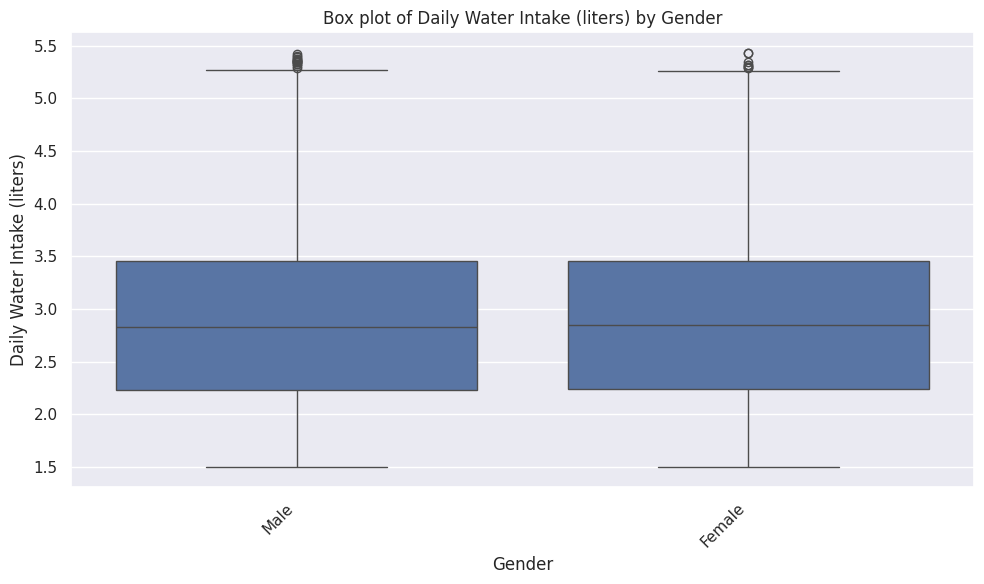

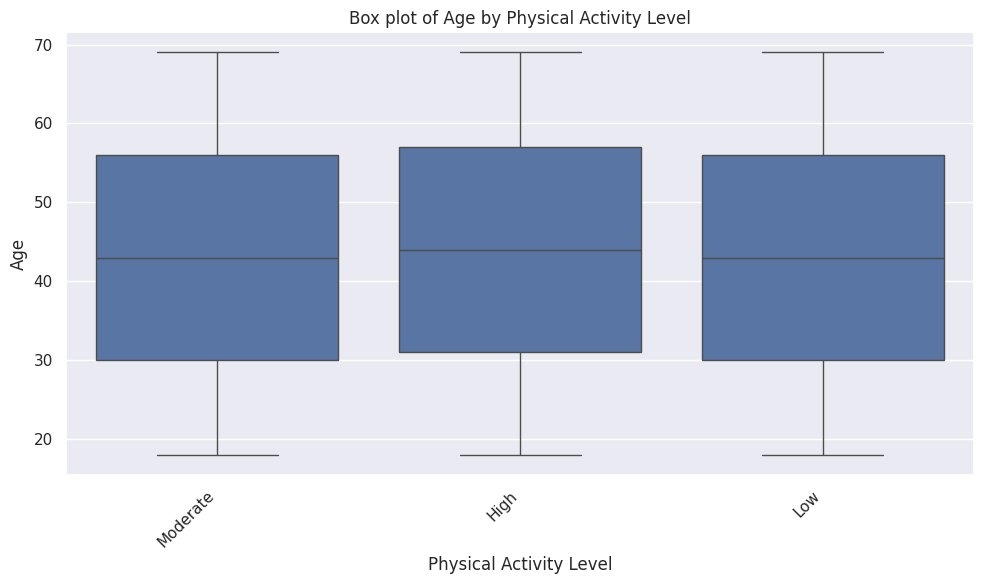

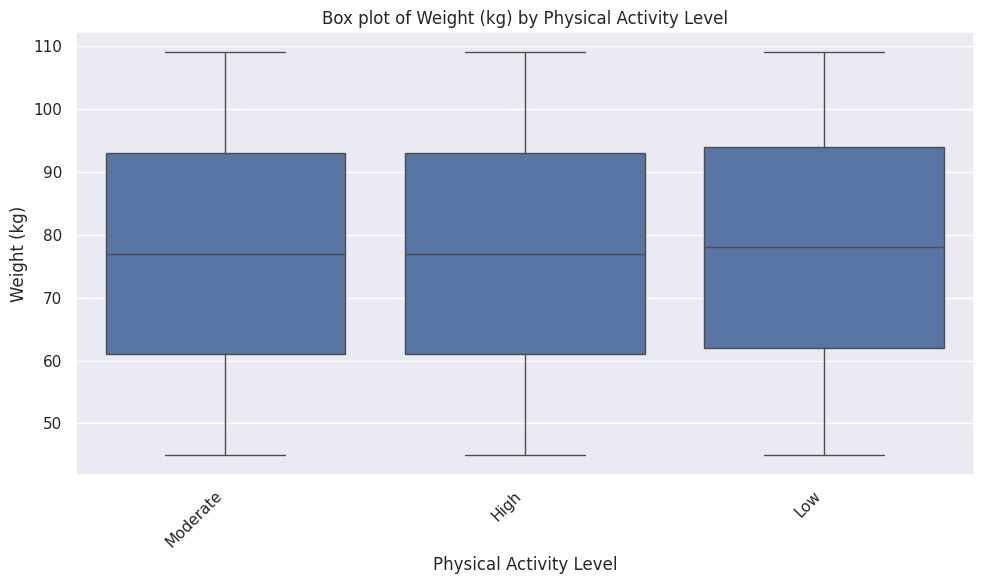

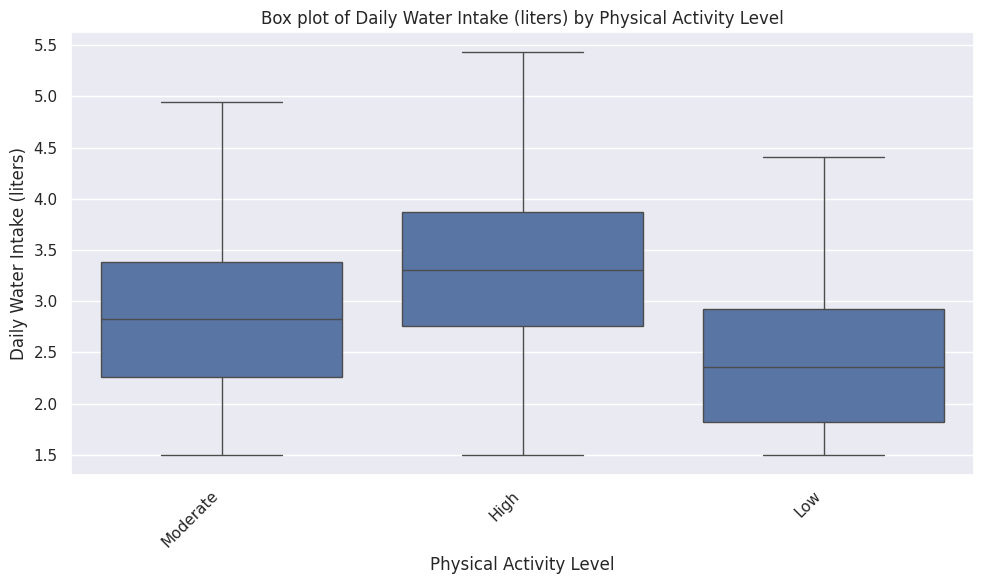

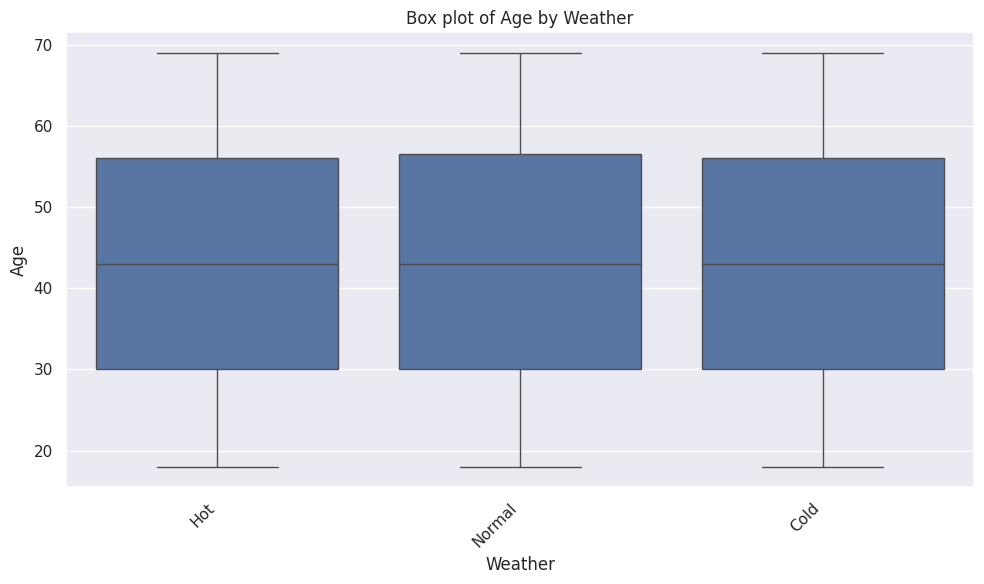

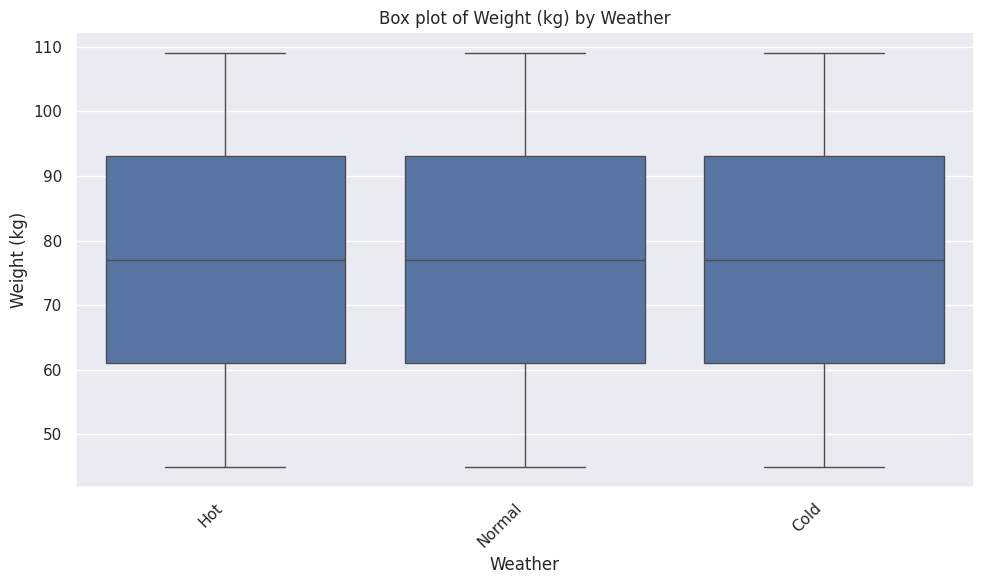

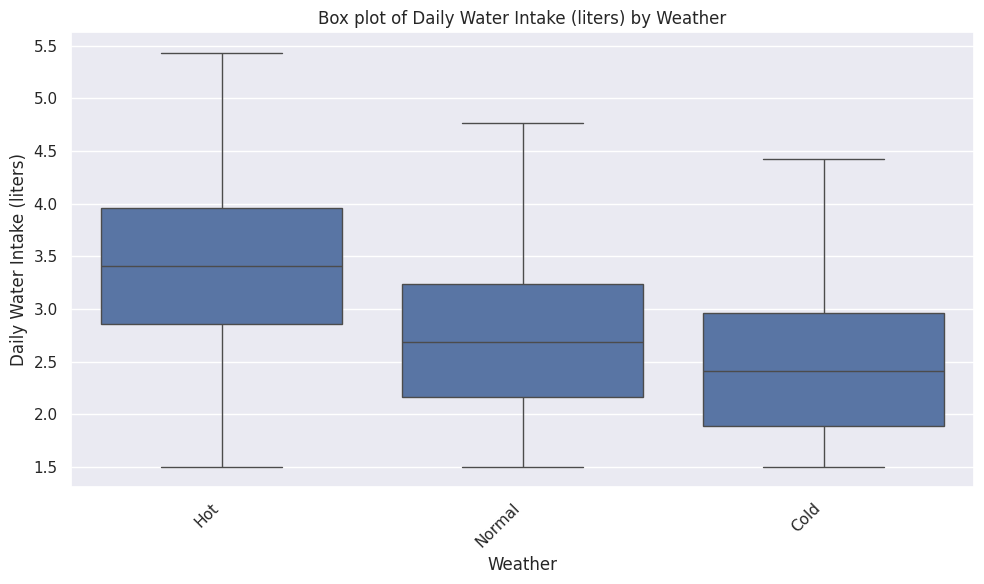

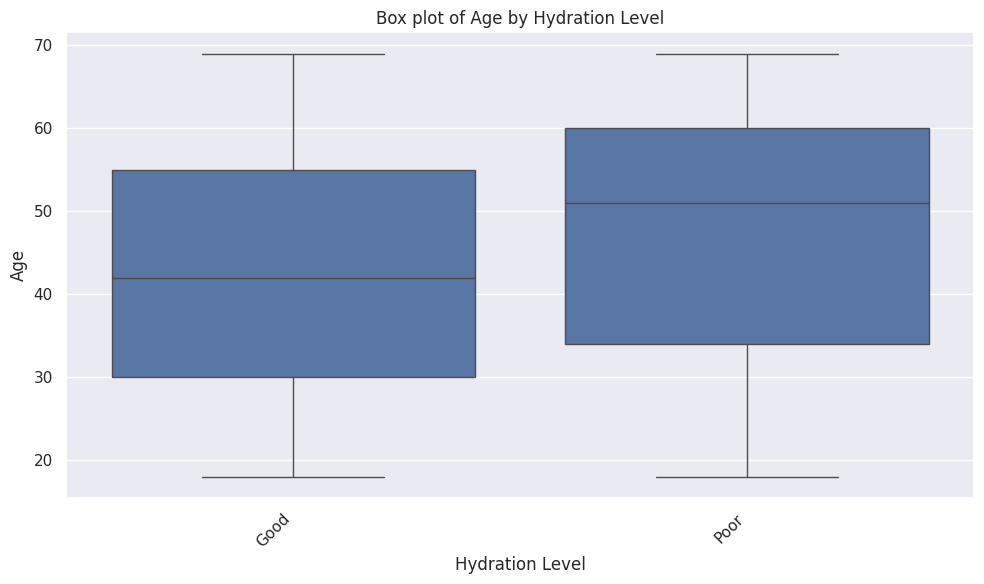

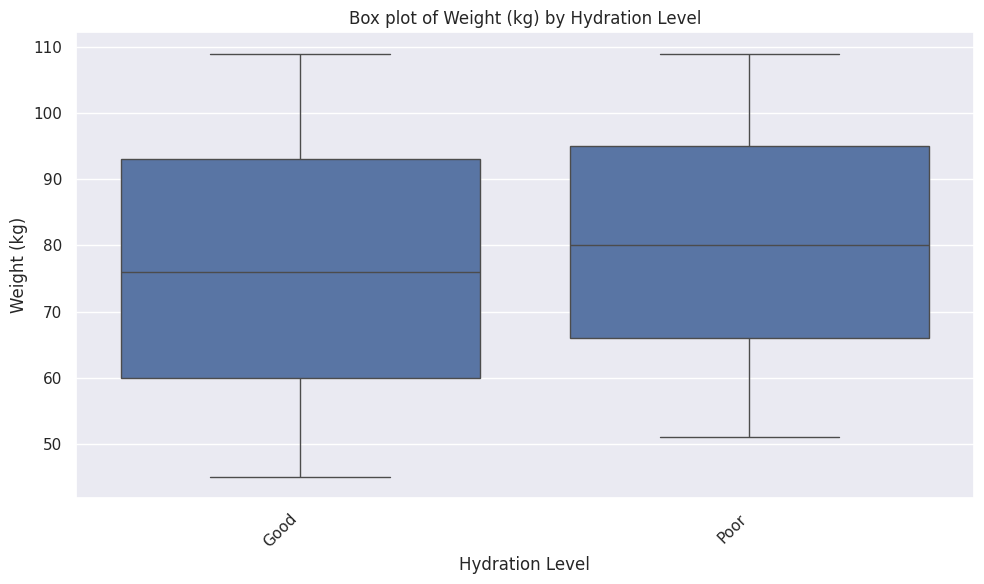

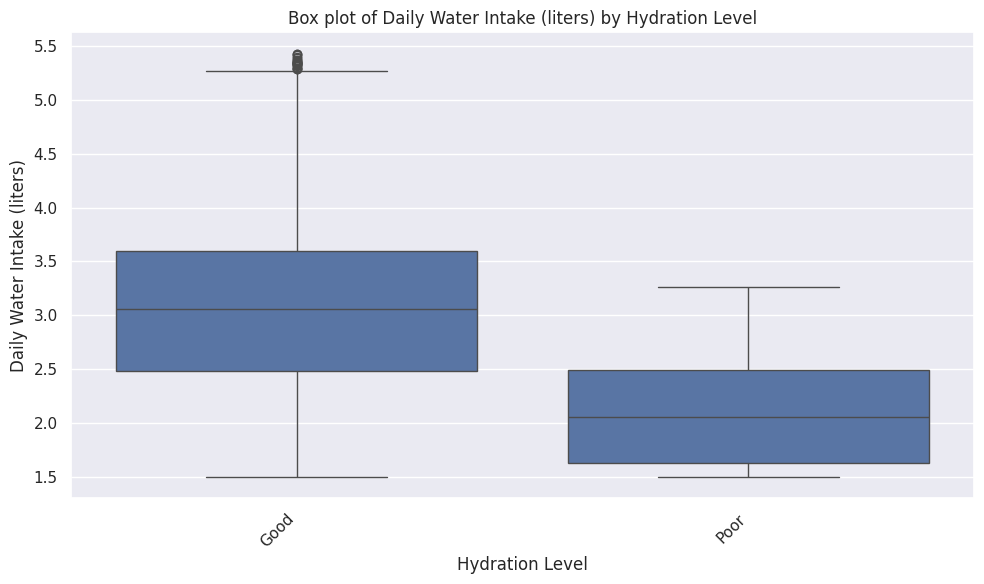

In [16]:
# Numerical-Numerical relationships (Scatter plots)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through pairs of numerical columns and create scatter plots
for i in range(len(numerical_cols)):
    for j in range(i + 1, len(numerical_cols)):
        col1 = numerical_cols[i]
        col2 = numerical_cols[j]
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x=col1, y=col2)
        plt.title(f'Scatter plot of {col1} vs {col2}')
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()

# Categorical-Numerical relationships (Box plots)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through categorical and numerical columns and create box plots
for cat_col in categorical_cols:
    for num_col in numerical_cols:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df, x=cat_col, y=num_col)
        plt.title(f'Box plot of {num_col} by {cat_col}')
        plt.xlabel(cat_col)
        plt.ylabel(num_col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

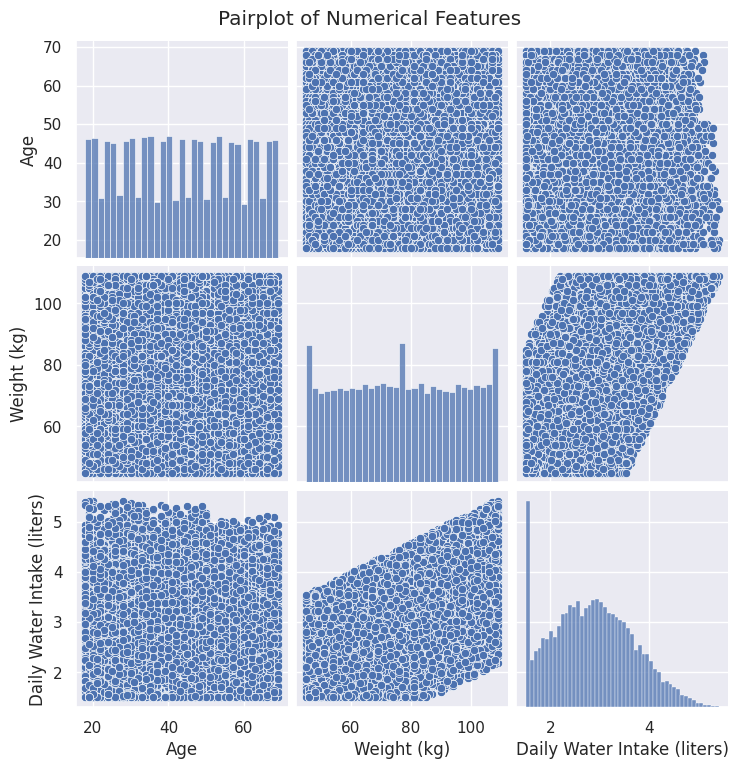

In [18]:
sns.pairplot(df.select_dtypes(include = np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

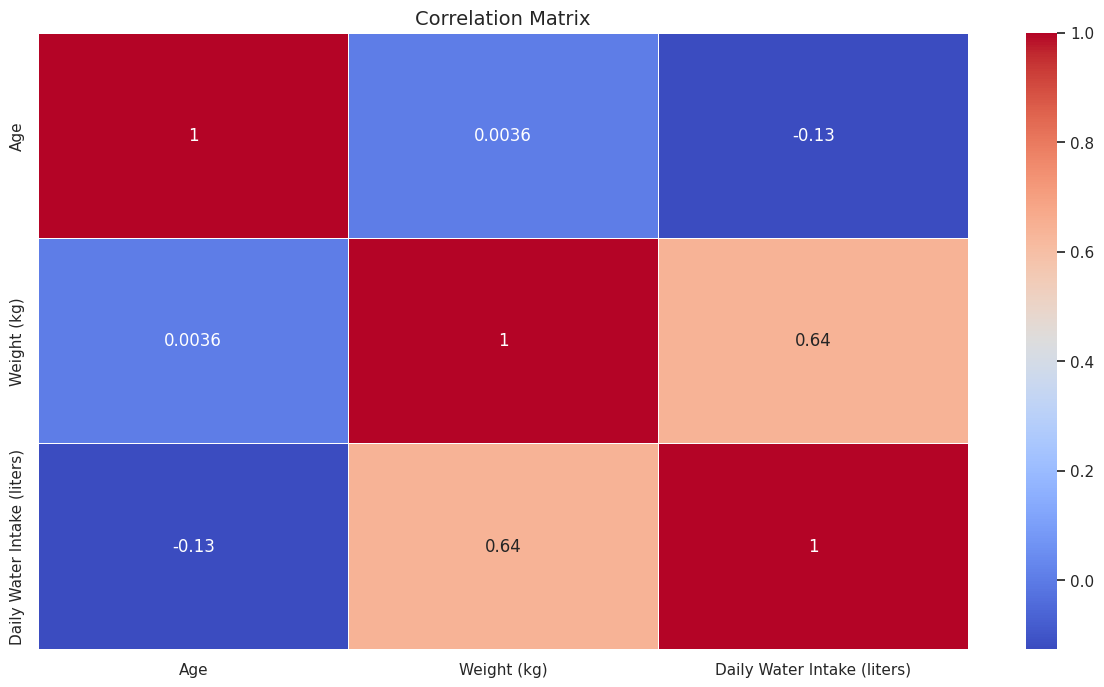

In [19]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Machine Learning

## Step-1: Prepare Data for Machine Learning

### Subtask:
Convert categorical features ('Gender', 'Physical Activity Level', 'Weather', 'Hydration Level') into a numerical format suitable for machine learning algorithms using one-hot encoding. Separate the features (X) from the target variable (y), which is 'Hydration Level'. Finally, split the dataset into training and testing sets to evaluate the model's performance on unseen data.


**Reasoning**:
The subtask requires converting categorical features to numerical format using one-hot encoding, separating features (X) and target (y), and then splitting the data into training and testing sets. I will first label encode the 'Hydration Level' column for the target variable 'y' and then one-hot encode the remaining categorical features ('Gender', 'Physical Activity Level', 'Weather') for the feature set 'X'. Finally, I will use `train_test_split` to create the training and testing datasets.



In [27]:
df.dtypes

,0
Age,int64
Gender,object
Weight (kg),int64
Daily Water Intake (liters),float64
Physical Activity Level,object
Weather,object
Hydration Level,object


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Make a copy of the dataframe to avoid modifying the original df
df_encoded = df.copy()

# 1. Label encode the 'Hydration Level' for the target variable
le = LabelEncoder()
df_encoded['Hydration Level_encoded'] = le.fit_transform(df_encoded['Hydration Level'])

# 2. Apply one-hot encoding to specified categorical features, excluding the original 'Hydration Level' column
categorical_features_for_ohe = ['Gender', 'Physical Activity Level', 'Weather']
df_encoded = pd.get_dummies(df_encoded, columns=categorical_features_for_ohe, drop_first=True)

# Drop the original 'Hydration Level' column as it's now encoded
df_encoded = df_encoded.drop('Hydration Level', axis=1)

# 3. Separate features (X) from the target variable (y)
X = df_encoded.drop('Hydration Level_encoded', axis=1)
y = df_encoded['Hydration Level_encoded']

# Display the shapes of X and y
print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

# 4. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("Data preparation for machine learning completed successfully.")

Shape of features (X): (29662, 8)
Shape of target (y): (29662,)
Shape of X_train: (23729, 8)
Shape of X_test: (5933, 8)
Shape of y_train: (23729,)
Shape of y_test: (5933,)
Data preparation for machine learning completed successfully.


## Train a Classification Model

### Subtask:
Select an appropriate classification algorithm (e.g., RandomForestClassifier) to predict the 'Hydration Level'. Train this model using the prepared training data (X_train, y_train).


**Reasoning**:
The subtask requires importing the `RandomForestClassifier`, instantiating it, and training the model using `X_train` and `y_train`.



In [24]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the RandomForestClassifier with a random state for reproducibility
model = RandomForestClassifier(random_state=42)

# Train the model using the training data
model.fit(X_train, y_train)

print("RandomForestClassifier model trained successfully.")

RandomForestClassifier model trained successfully.


## Evaluate Model Performance

### Subtask:
Use the trained model to make predictions on the test set (X_test). Calculate and display key classification metrics such as accuracy, precision, recall, and F1-score. Additionally, visualize the confusion matrix to understand the types of correct and incorrect predictions made by the model.


**Reasoning**:
To evaluate the trained model, I will first make predictions on the test set, then calculate and display key classification metrics such as accuracy, precision, recall, and F1-score, and finally visualize the confusion matrix.



Accuracy: 0.9857
Precision: 0.9792
Recall: 0.9515
F1-Score: 0.9651


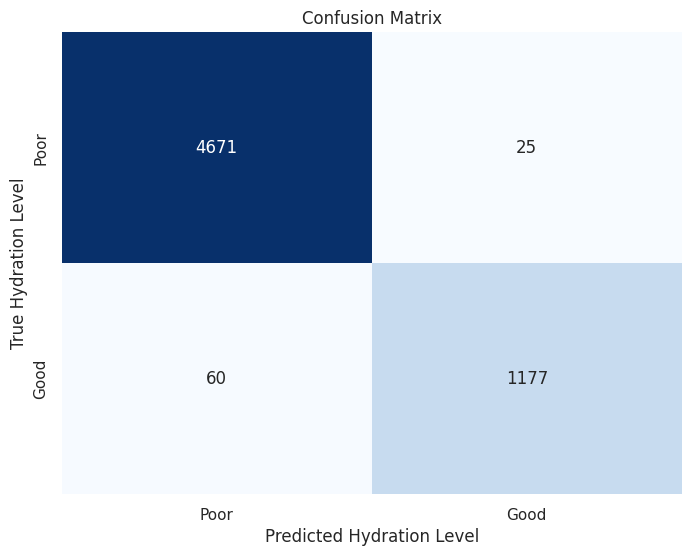

Model evaluation completed successfully.


In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Make predictions on the test set
y_pred = model.predict(X_test)

# 2. Calculate key classification metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# 3. Print the calculated metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# 4. Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# 5. Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Poor', 'Good'], yticklabels=['Poor', 'Good'])
plt.xlabel('Predicted Hydration Level')
plt.ylabel('True Hydration Level')
plt.title('Confusion Matrix')
plt.show()

print("Model evaluation completed successfully.")

## Visualize Feature Importance


**Reasoning**:
To visualize feature importances, I will first access the `feature_importances_` attribute of the trained model. Then, I will create a pandas Series to map these importance scores to their corresponding feature names from the `X_train` DataFrame and sort them in descending order. Finally, I will use a bar plot to visualize these importances, adding appropriate titles and labels for clarity.



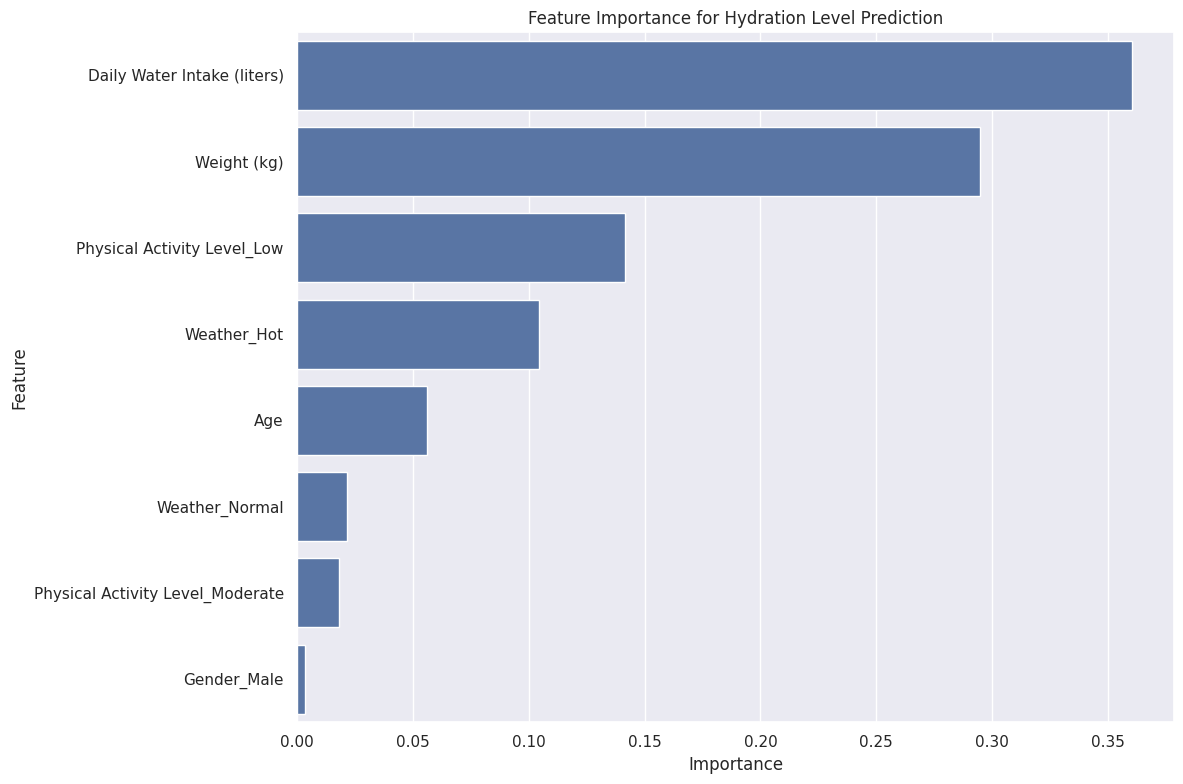

Feature importance visualization completed successfully.


In [28]:
# 1. Access the feature_importances_ attribute
feature_importances = model.feature_importances_

# 2. Create a Pandas Series to map importance scores to feature names
features = X_train.columns
feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})

# 3. Sort the features by their importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 4. Create a bar plot to visualize the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance for Hydration Level Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()

# 5. Display the plot
plt.show()

print("Feature importance visualization completed successfully.")

## Summary:

### Data Analysis Key Findings

*   **Data Preparation:** The 'Hydration Level' column was label encoded as the target variable `y`, and categorical features 'Gender', 'Physical Activity Level', and 'Weather' were successfully one-hot encoded to form the feature set `X`. The dataset was split into training (`X_train`, `y_train`) and testing (`X_test`, `y_test`) sets, comprising 23,729 and 5,933 samples respectively, with 8 features each.
*   **Model Training:** A `RandomForestClassifier` model was successfully trained using the prepared training data.
*   **Model Performance:** The trained model demonstrated high performance on the test set, achieving an Accuracy of 0.9857, Precision of 0.9792, Recall of 0.9515, and an F1-Score of 0.9651. A confusion matrix was also generated to visualize classification results.
*   **Feature Importance:** Feature importances were extracted from the trained model and visualized, providing insights into which factors contribute most significantly to the prediction of hydration levels.

### Insights or Next Steps

*   The trained `RandomForestClassifier` exhibits excellent predictive capabilities for hydration levels, as indicated by its high accuracy (98.57\%) and F1-score (96.51\%). This suggests the selected features are strong indicators for hydration.
*   Further analysis of the feature importance visualization is crucial to identify the specific features that have the most substantial impact on hydration. This understanding can guide the development of targeted strategies or recommendations for maintaining optimal hydration.


# Thank You